# EDA — Hull Tactical Market Prediction (v2)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
df = pd.read_csv("../../data/raw/train.csv")
print(f"Shape: {df.shape}  |  date_id range: {df['date_id'].min()} – {df['date_id'].max()}")

Shape: (9048, 98)  |  date_id range: 0 – 9047


## 1. Feature Missingness over Time

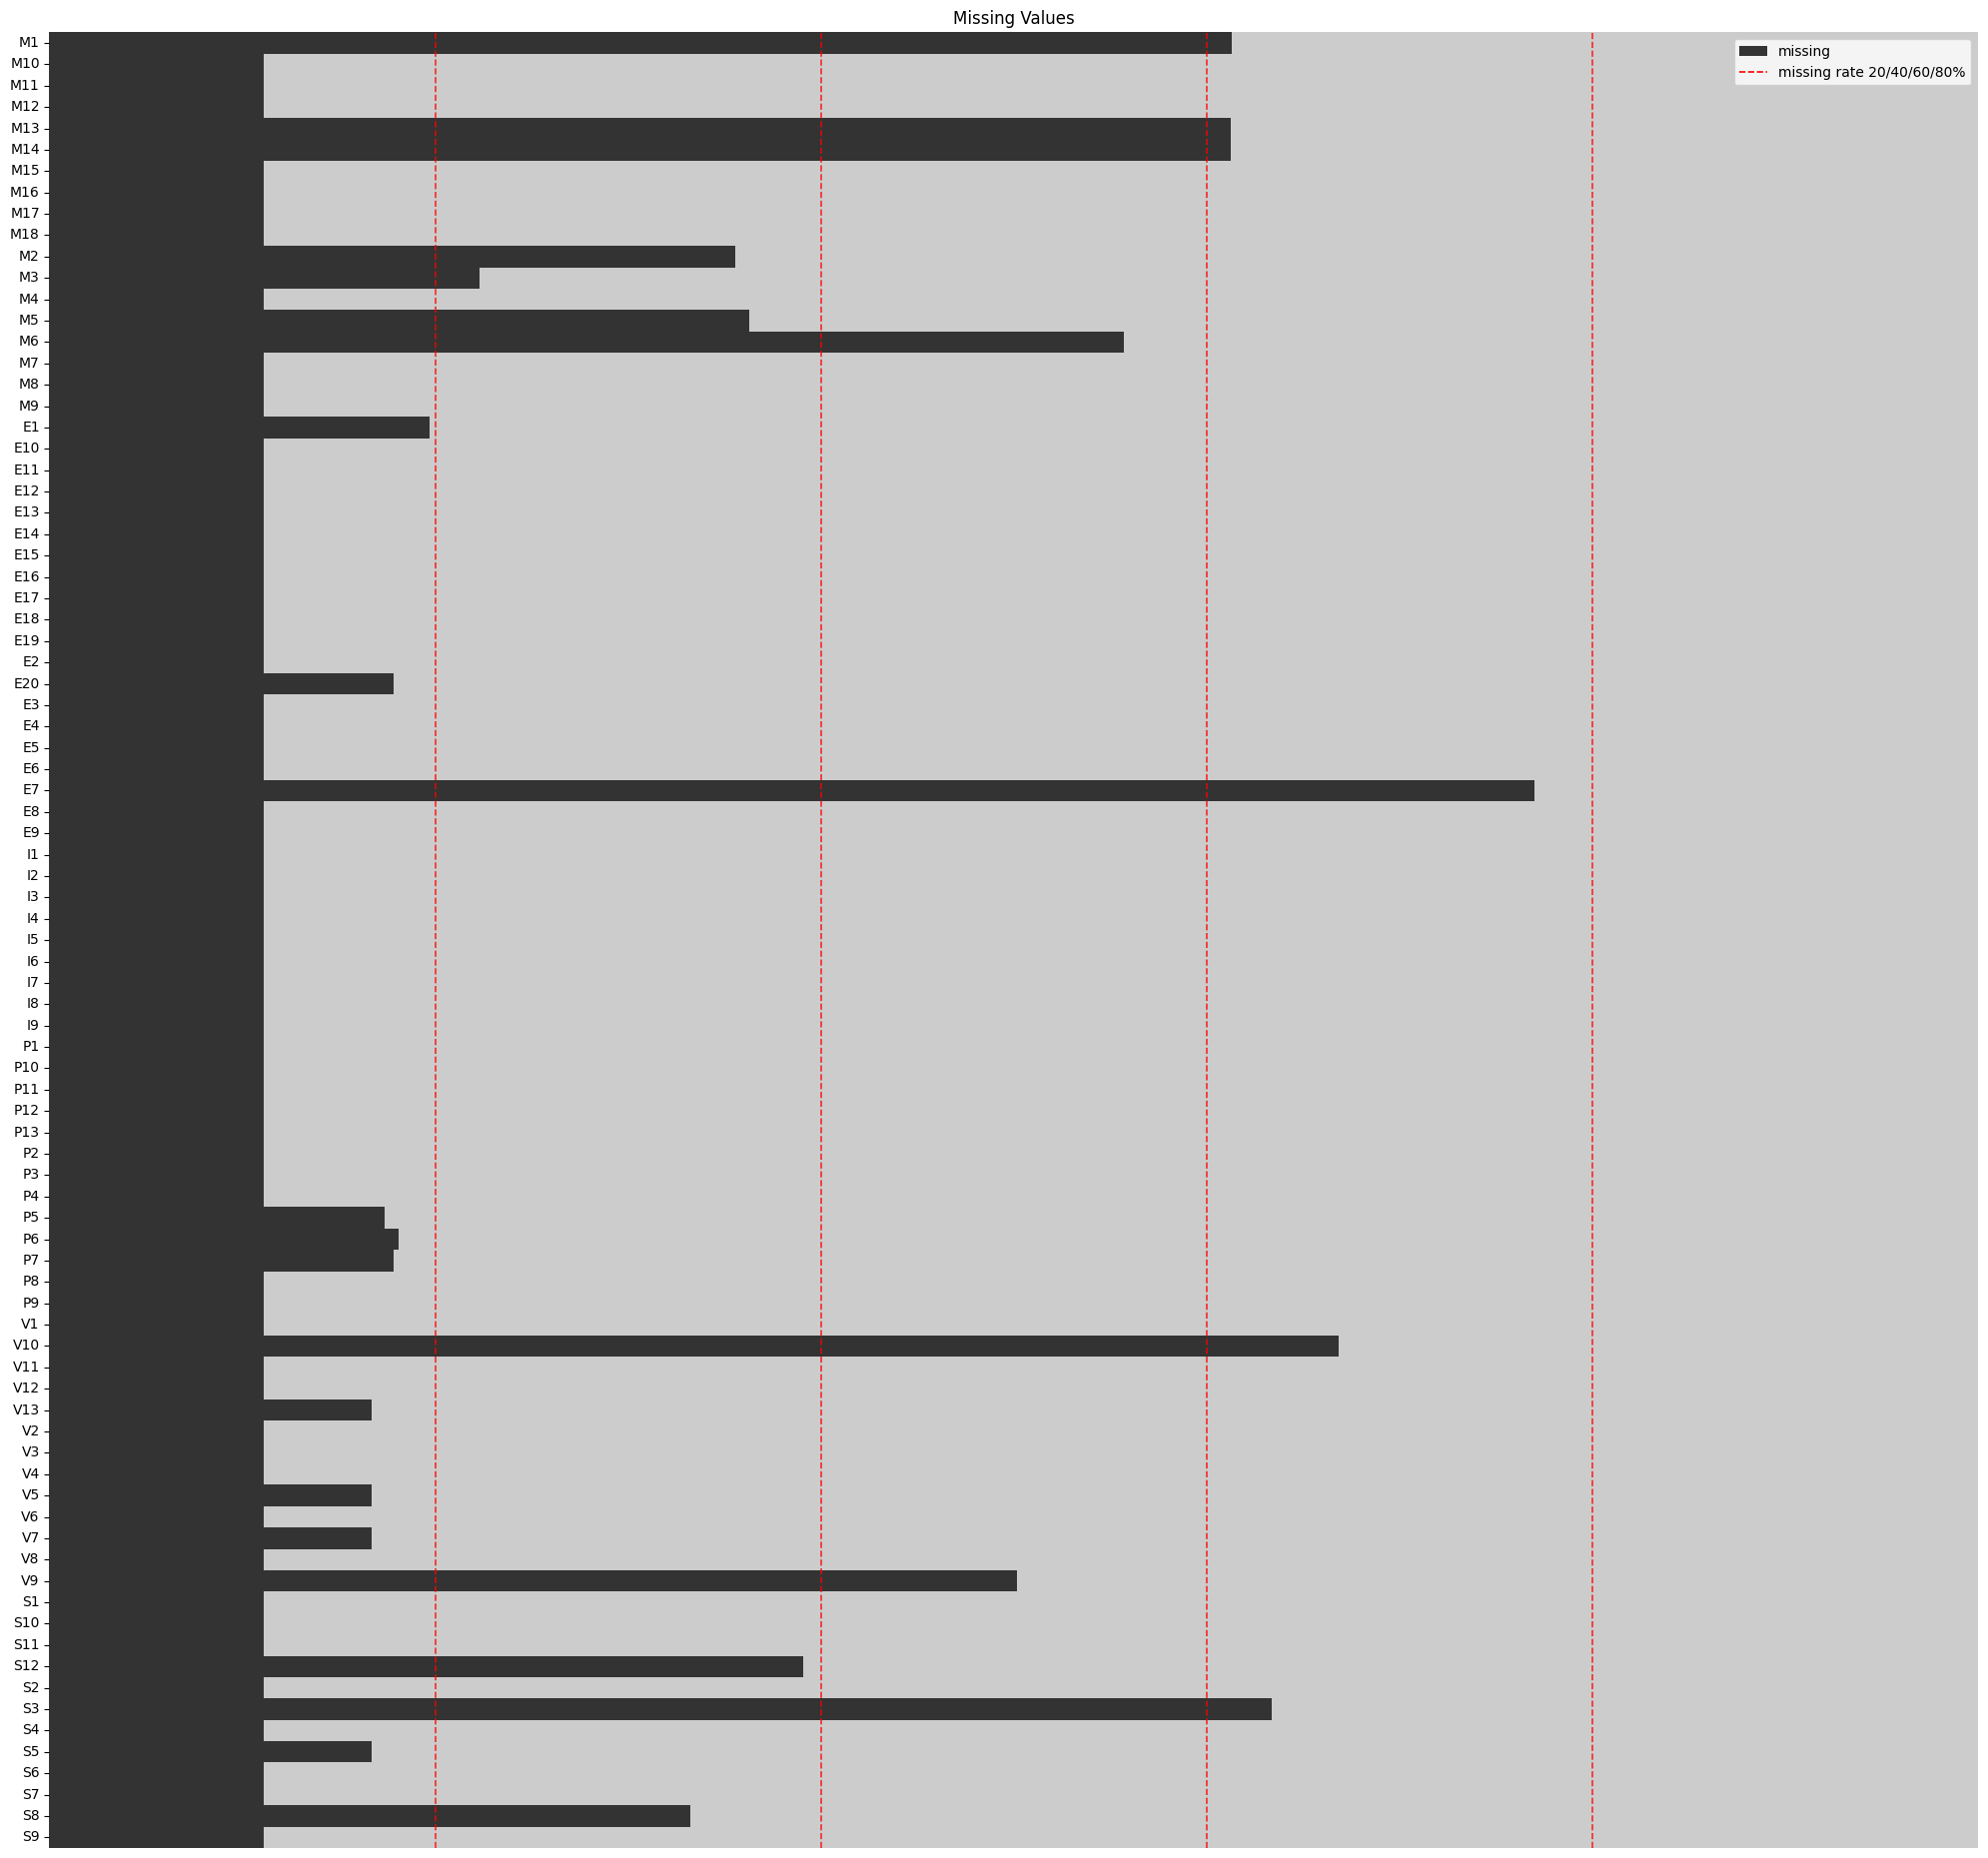

In [3]:
prefixes = ["M", "E", "I", "P", "V", "S", "MOM"]
feat_cols = []
for p in prefixes:
    cols = sorted(c for c in df.columns if c.startswith(p))
    feat_cols.extend(cols)

missing_bool = df[feat_cols].isna()
n_cols = len(feat_cols)

fig, ax = plt.subplots(figsize=(20, max(10, n_cols * 0.22)))
sns.heatmap(
    missing_bool.T, ax=ax,
    cmap=["#CCCCCC", "#333333"],
    cbar=False,
    yticklabels=True, xticklabels=False,
)

# missing rate 20/40/60/80%虚线
n_rows = len(df)
for pct in [0.2, 0.4, 0.6, 0.8]:
    ax.axvline(n_rows * pct, color="red", linewidth=1.2, linestyle="--", alpha=0.8)

# 图例
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.legend(
    handles=[
        Patch(facecolor="#333333", label="missing"),
        Line2D([0], [0], color="red", linewidth=1.2, linestyle="--", label="missing rate 20/40/60/80%"),
    ],
    loc="upper right", framealpha=0.8
)

ax.set_title("Missing Values")
plt.tight_layout()
plt.show()

## 2. Outlier Inspection — Boxplots

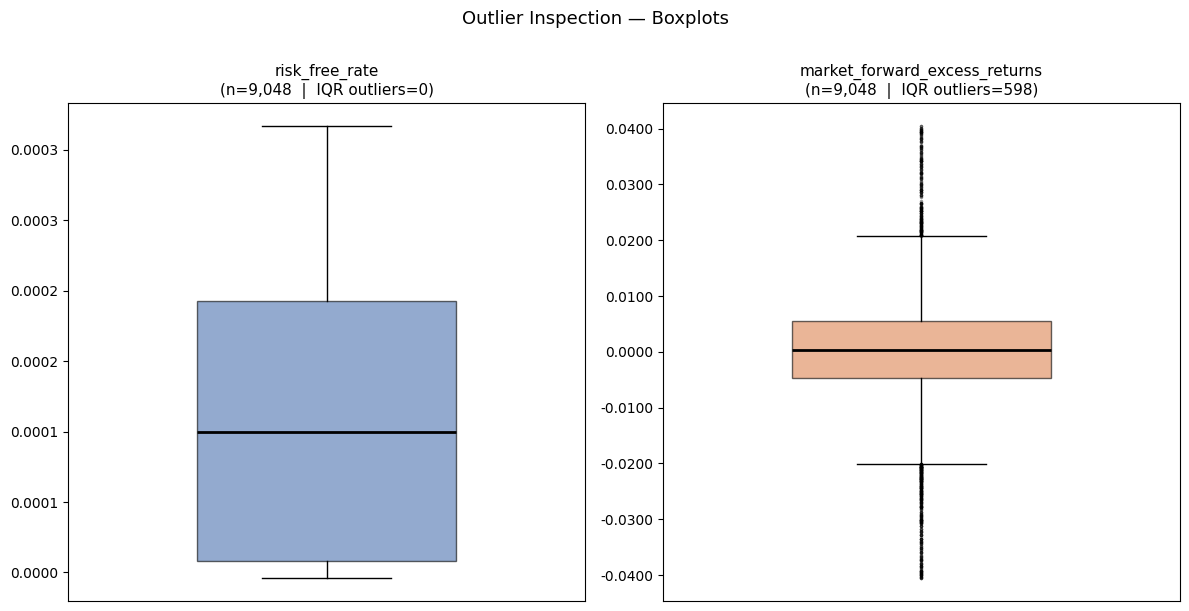

In [4]:
box_cols = ["risk_free_rate", "market_forward_excess_returns"]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
palette = ["#4C72B0", "#DD8452"]

for ax, col, color in zip(axes, box_cols, palette):
    data = df[col].dropna()
    ax.boxplot(
        data, vert=True, patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker=".", markersize=3, alpha=0.4, color=color),
        widths=0.5,
    )
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    n_out = int(((data < q1 - 1.5 * (q3 - q1)) | (data > q3 + 1.5 * (q3 - q1))).sum())
    ax.set_title(f"{col}\n(n={len(data):,}  |  IQR outliers={n_out:,})", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
    ax.set_xticks([])

fig.suptitle("Outlier Inspection — Boxplots", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Target & Risk-Free Rate Distributions

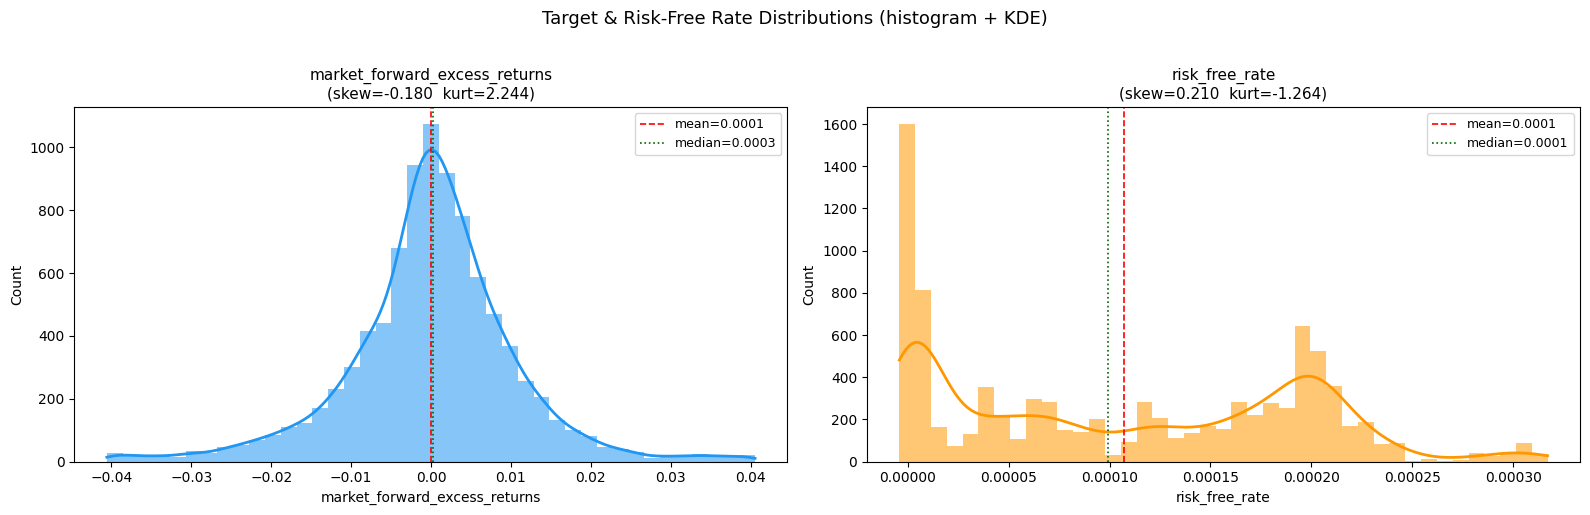

In [5]:
dist_cols = ["market_forward_excess_returns", "risk_free_rate"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["#2196F3", "#FF9800"]

for ax, col, color in zip(axes, dist_cols, colors):
    data = df[col].dropna()
    n_bins_hist = min(150, int(2 * len(data) ** (1 / 3)))
    sns.histplot(data, bins=n_bins_hist, kde=True, ax=ax, color=color, alpha=0.55,
                 line_kws={"linewidth": 2, "color": color}, edgecolor="none")
    ax.axvline(data.mean(), color="red", linewidth=1.2, linestyle="--",
               label=f"mean={data.mean():.4f}")
    ax.axvline(data.median(), color="darkgreen", linewidth=1.2, linestyle=":",
               label=f"median={data.median():.4f}")
    ax.legend(fontsize=9)
    ax.set_title(f"{col}\n(skew={data.skew():.3f}  kurt={data.kurt():.3f})", fontsize=11)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)

fig.suptitle("Target & Risk-Free Rate Distributions (histogram + KDE)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

market_forward_excess_returns分布接近正态，均值与中位数均趋近于零（0.0001 vs 0.0003），轻微左偏（skew = -0.180），反映股市"涨慢跌快"的典型特征。峰度为 2.244，略低于正态分布的 3，这与目标变量经过 MAD winsorizing 处理后极值被压缩有关。整体而言分布较为对称，适合直接作为回归目标。

risk_free_rate分布呈显著双峰形态，左峰集中于 0-0.00005 附近，对应低利率时期；右峰集中于 0.00018-0.00022，对应正常及偏紧的货币政策周期。整体轻微右偏（skew = 0.210），由右峰分布更分散且存在右侧长尾所致。据此，可在后续特征工程构造一列高/低利率regime哑变量，并将阈值设定为0.0001（对应年化约 2.5%）